In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import pandas as pd

path = r"C:/Users/ambis/Desktop/python files/Bookings-600000-Rows.xlsx"
df = pd.read_excel(path)

print(df.head(5))

         Date      Time     Booking_ID        Booking_Status Customer_ID  \
0  2026-03-18  13:20:53  CNR9775832491               Success   CID129739   
1  2026-02-27  07:50:13  CNR7860266133    Canceled by Driver   CID162656   
2  2026-02-16  00:03:16  CNR4558925211               Success   CID259886   
3  2026-01-25  06:44:21  CNR5422306246  Canceled by Customer   CID470991   
4  2026-01-28  16:54:41  CNR1580363943               Success   CID855933   

  Vehicle_Type Pickup_Location  Drop_Location  V_TAT  C_TAT  \
0  Prime Sedan     Rajajinagar  Sarjapur Road  263.9   41.4   
1         Auto      Hosur Road    Rajajinagar   84.1   37.0   
2        eBike      Whitefield        Varthur  289.9   25.7   
3   Prime Plus     Tumkur Road        Varthur   53.3   48.2   
4    Prime SUV          Peenya      Jayanagar  189.0  113.8   

                     Canceled_Rides_by_Customer    Canceled_Rides_by_Driver  \
0                                           NaN                         NaN   
1     

In [4]:
df.shape

(600000, 20)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        600000 non-null  str    
 1   Time                        600000 non-null  str    
 2   Booking_ID                  600000 non-null  str    
 3   Booking_Status              600000 non-null  str    
 4   Customer_ID                 600000 non-null  str    
 5   Vehicle_Type                600000 non-null  str    
 6   Pickup_Location             600000 non-null  str    
 7   Drop_Location               600000 non-null  str    
 8   V_TAT                       600000 non-null  float64
 9   C_TAT                       600000 non-null  float64
 10  Canceled_Rides_by_Customer  72310 non-null   str    
 11  Canceled_Rides_by_Driver    60131 non-null   str    
 12  Incomplete_Rides            371298 non-null  str    
 13  Incomplete_Rides_Reason  

In [6]:
df.describe()

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,121.042718,62.018495,1550.136633,24.961047,3.357353,3.357679
std,92.085052,42.378867,836.355804,14.143358,1.569383,1.569173
min,0.000000,0.000000,100.000000,1.000000,0.000000,0.000000
25%,50.900000,32.800000,827.000000,13.000000,3.200000,3.200000
50%,95.000000,54.600000,1550.000000,25.000000,3.800000,3.800000
75%,197.800000,96.600000,2274.000000,37.000000,4.400000,4.400000
max,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000


In [7]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

Incomplete_Rides_Reason       581254
Canceled_Rides_by_Driver      539869
Vehicle Images                534470
Canceled_Rides_by_Customer    527690
Incomplete_Rides              228702
Payment_Method                228702
Time                               0
Date                               0
Booking_Status                     0
Booking_ID                         0
Customer_ID                        0
Vehicle_Type                       0
V_TAT                              0
C_TAT                              0
Pickup_Location                    0
Drop_Location                      0
Booking_Value                      0
Ride_Distance                      0
Driver_Ratings                     0
Customer_Rating                    0
dtype: int64

In [14]:
df.fillna({
    'Payment_Method': "Unknown",
    'Incomplete_Rides': "NA",
    'Canceled_Rides_by_Customer': "NA",
    'Canceled_Rides_by_Driver': "NA"
}, inplace=True)

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2026-03-18,13:20:53,CNR9775832491,Success,CID129739,Prime Sedan,Rajajinagar,Sarjapur Road,263.9,41.4,No,No,No,NaN,1321,UPI,13,3.6,4.6,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2026-02-27,07:50:13,CNR7860266133,Canceled by Driver,CID162656,Auto,Hosur Road,Rajajinagar,84.1,37.0,No,Customer was coughing/sick,No,NaN,211,Unknown,6,3.4,3.9,https://cdn-icons-png.flaticon.com/128/16526/1...
2,2026-02-16,00:03:16,CNR4558925211,Success,CID259886,eBike,Whitefield,Varthur,289.9,25.7,No,No,No,NaN,1380,UPI,32,4.3,4.2,https://cdn-icons-png.flaticon.com/128/6839/68...
3,2026-01-25,06:44:21,CNR5422306246,Canceled by Customer,CID470991,Prime Plus,Tumkur Road,Varthur,53.3,48.2,Driver is not moving towards pickup location,No,No,NaN,898,Unknown,27,4.0,3.6,https://cdn-icons-png.flaticon.com/128/11409/1...
4,2026-01-28,16:54:41,CNR1580363943,Success,CID855933,Prime SUV,Peenya,Jayanagar,189.0,113.8,No,No,No,NaN,2286,Cash,21,4.0,3.9,https://cdn-icons-png.flaticon.com/128/9983/99...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,2026-03-05,05:26:00,CNR2271462294,Success,CID356120,Prime Plus,Bannerghatta Road,RT Nagar,70.1,129.2,No,No,No,NaN,1985,Credit Card,46,3.0,3.3,NaN
599996,2026-01-10,23:46:05,CNR6609132075,Success,CID776799,Prime Sedan,Sahakar Nagar,Jayanagar,49.4,108.9,No,No,No,NaN,550,Credit Card,45,3.7,4.8,NaN
599997,2026-03-10,05:34:44,CNR7471264193,Driver Not Found,CID335302,Bike,Peenya,Vijayanagar,0.0,0.0,No,No,No,NaN,2452,Unknown,6,0.0,0.0,NaN
599998,2026-02-25,05:21:02,CNR5435757297,Success,CID639821,Auto,Sahakar Nagar,Hosur Road,130.0,68.8,No,No,No,NaN,845,Credit Card,8,3.0,3.1,NaN


In [15]:
df.describe()

,Date,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
count,600000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,2026-02-14 13:02:33.503999,121.042718,62.018495,1550.136633,24.961047,3.357353,3.357679
min,2026-01-01 00:00:00,0.000000,0.000000,100.000000,1.000000,0.000000,0.000000
25%,2026-01-23 00:00:00,50.900000,32.800000,827.000000,13.000000,3.200000,3.200000
50%,2026-02-15 00:00:00,95.000000,54.600000,1550.000000,25.000000,3.800000,3.800000
75%,2026-03-09 00:00:00,197.800000,96.600000,2274.000000,37.000000,4.400000,4.400000
max,2026-03-31 00:00:00,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000
std,NaN,92.085052,42.378867,836.355804,14.143358,1.569383,1.569173


In [16]:
vechical = df["Vehicle_Type"].value_counts()
vechical 


Vehicle_Type
Prime Sedan    86109
Prime Plus     85881
Bike           85866
Auto           85740
eBike          85693
Mini           85413
Prime SUV      85298
Name: count, dtype: int64

In [21]:
total_rev = df["Booking_Value"].sum()
avg_value = df["Booking_Value"].mean()

print(total_rev)
print(avg_value)

930081980
1550.1366333333333


In [24]:
top_pickup = df['Pickup_Location'].value_counts(ascending=False).head(10)
top_pickup

Pickup_Location
Kadugodi             35817
Bannerghatta Road    35725
Sarjapur Road        35544
Varthur              35481
Whitefield           35422
Tumkur Road          35315
Magadi Road          35309
Jayanagar            35282
RT Nagar             35214
Hosur Road           35208
Name: count, dtype: int64

In [25]:
top_drop = df["Drop_Location"].value_counts(ascending=False)
top_drop.head(10)

Drop_Location
Bannerghatta Road    35509
Whitefield           35469
Chamarajpet          35444
RT Nagar             35426
Vijayanagar          35425
Kadugodi             35369
HSR Layout           35360
Sarjapur Road        35313
Varthur              35308
Peenya               35290
Name: count, dtype: int64

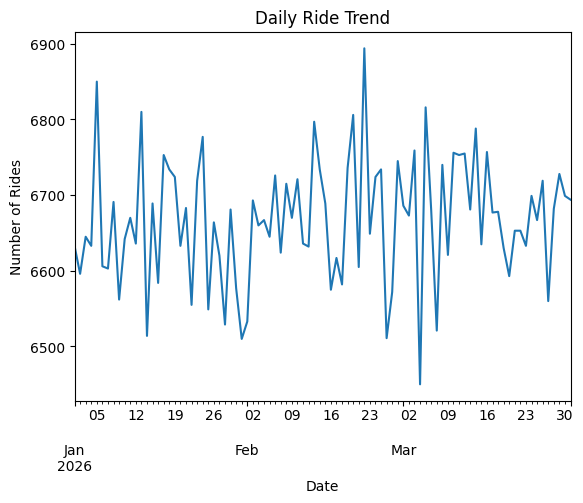

In [32]:
daily_rides = df.groupby('Date').size()

plt.figure()
daily_rides.plot()
plt.title("Daily Ride Trend")
plt.xlabel("Date")
plt.ylabel("Number of Rides")
plt.show()

In [34]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour

Hour
0    25159
1    24987
2    25176
3    24797
4    25194
dtype: int64


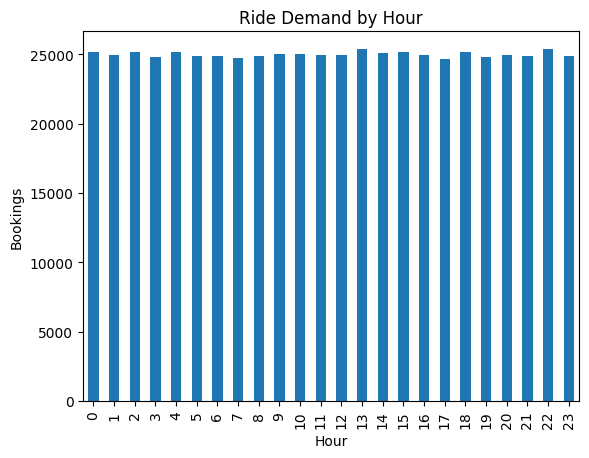

In [36]:
hourly = df.groupby('Hour').size()

print(hourly.head())   # make sure it's not empty

plt.figure()
hourly.plot(kind='bar')
plt.title("Ride Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Bookings")
plt.show()

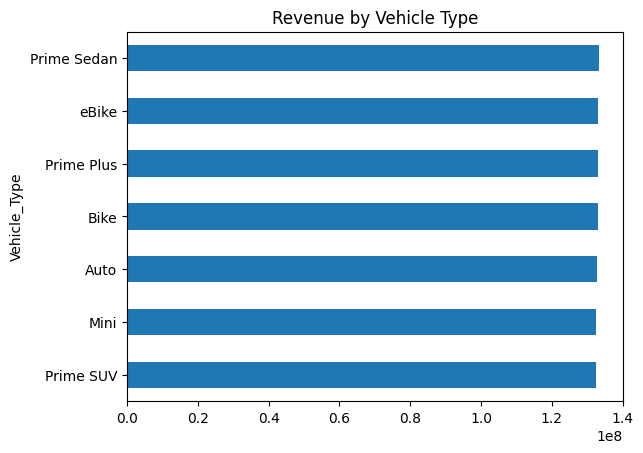

In [37]:
vehicle_revenue = df.groupby('Vehicle_Type')['Booking_Value'].sum().sort_values()

plt.figure()
vehicle_revenue.plot(kind='barh')
plt.title("Revenue by Vehicle Type")
plt.show()

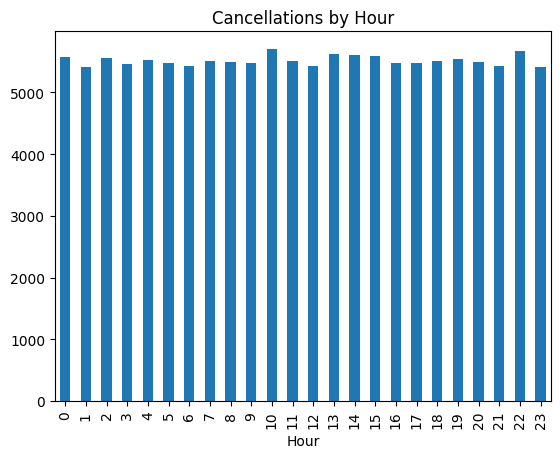

In [38]:
cancel_df = df[df['Booking_Status'].str.contains("Canceled", na=False)]

cancel_by_hour = cancel_df.groupby('Hour').size()

plt.figure()
cancel_by_hour.plot(kind='bar')
plt.title("Cancellations by Hour")
plt.show()

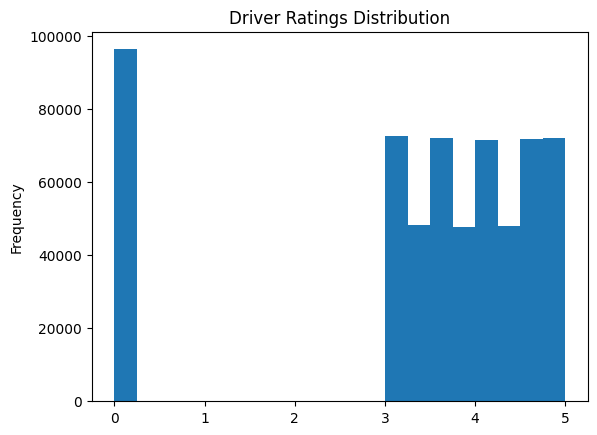

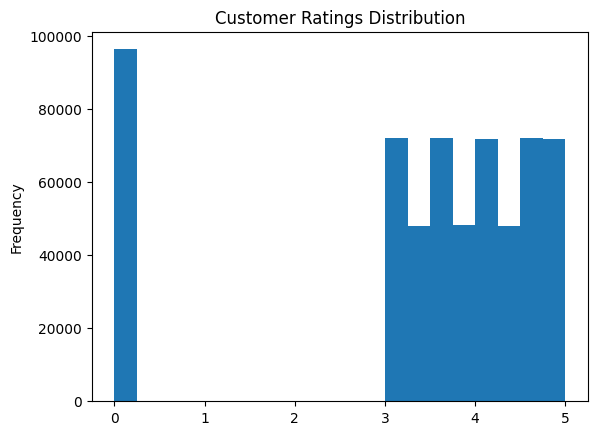

In [40]:
plt.figure()
df['Driver_Ratings'].plot(kind='hist', bins=20)
plt.title("Driver Ratings Distribution")
plt.show()

plt.figure()
df['Customer_Rating'].plot(kind='hist', bins=20)
plt.title("Customer Ratings Distribution")
plt.show()

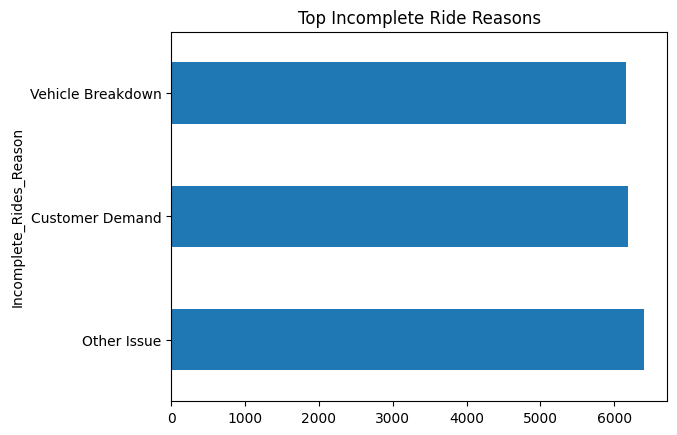

In [41]:
reasons = df['Incomplete_Rides_Reason'].value_counts().head(10)

plt.figure()
reasons.plot(kind='barh')
plt.title("Top Incomplete Ride Reasons")
plt.show()

In [42]:
# Cancellation Rate
cancel_rate = (df['Booking_Status'].str.contains("Canceled").sum() / len(df)) * 100

# Completion Rate
complete_rate = (df['Booking_Status'] == "Completed").mean() * 100

# Avg Distance
avg_distance = df['Ride_Distance'].mean()

# Avg Fare
avg_fare = df['Booking_Value'].mean()

print(f"Cancel Rate: {cancel_rate:.2f}%")
print(f"Completion Rate: {complete_rate:.2f}%")
print(f"Avg Distance: {avg_distance:.2f}")
print(f"Avg Fare: {avg_fare:.2f}")

Cancel Rate: 22.07%
Completion Rate: 0.00%
Avg Distance: 24.96
Avg Fare: 1550.14
